Name: Syeda Qurrath Ul Ain

 Module: Supervised Machine Learning (Module 5)

Task 1: Load Data & Feature Engineering

In [19]:
#Load 3 years of stock data and create important features for prediction

import pandas as pd
import numpy as np
import yfinance as yf

stock = "AAPL"
df = yf.download(stock, period="3y")

# Feature Engineering
df['Daily_Return'] = df['Close'].pct_change()
df['Price_Range'] = df['High'] - df['Low']
df['20D_MA'] = df['Close'].rolling(20).mean()
df['50D_MA'] = df['Close'].rolling(50).mean()

df = df.dropna()
df.head()

/tmp/ipykernel_8949/2706399240.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, period="3y")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Daily_Return,Price_Range,20D_MA,50D_MA
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,
Date,,,,,,,,,
2023-07-06,189.332413,189.539707,186.756125,187.387858,45094300,0.002509,2.783582,183.879783,175.815842
2023-07-07,188.216995,190.181296,187.782691,188.937577,46815000,-0.005891,2.398605,184.514475,176.351555
2023-07-10,186.173767,187.535947,184.624039,186.815365,59922200,-0.010856,2.911908,184.911283,176.846601
2023-07-11,185.650604,186.854847,184.189725,186.716656,46638100,-0.002810,2.665122,185.262685,177.239513
2023-07-12,187.318787,189.223850,186.035575,187.229938,60750200,0.008986,3.188275,185.557822,177.640750


Task 2: Create Target Variable

In [20]:
#Create UP/DOWN label for classification

df['Target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)
df = df.dropna()

print(df['Target'].value_counts())



Target
1    380
0    324
Name: count, dtype: int64


Task 3: Train-Test Split & Scaling


In [21]:
#Split dataset and scale features

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = ['Open','High','Low','Volume','20D_MA','50D_MA','Daily_Return','Price_Range']
X = df[features]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Task 4: Linear Regression

In [22]:
#Predict actual stock price

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

RMSE: 0.49937194419856384
R2 Score: -0.001569992879475901


Task 5: Plot Actual vs Predicted

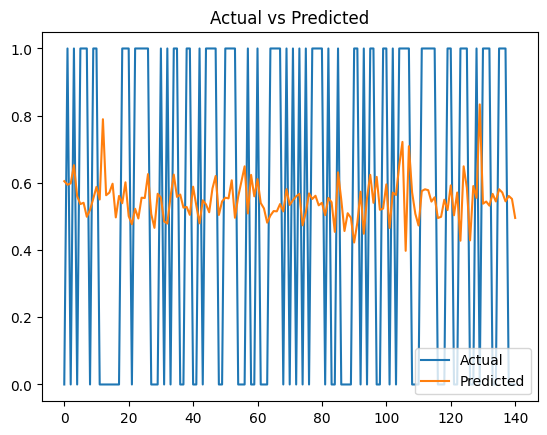

In [23]:
#Visualize model performance

import matplotlib.pyplot as plt

plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

Task 6: Logistic Regression

In [24]:
#Predict UP/DOWN direction

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5319148936170213
[[ 8 58]
 [ 8 67]]
              precision    recall  f1-score   support

           0       0.50      0.12      0.20        66
           1       0.54      0.89      0.67        75

    accuracy                           0.53       141
   macro avg       0.52      0.51      0.43       141
weighted avg       0.52      0.53      0.45       141



Task 7: Decision Tree

In [25]:
#Analyze performance with different depths

from sklearn.tree import DecisionTreeClassifier

for depth in range(3,11):
    dt = DecisionTreeClassifier(max_depth=depth)
    dt.fit(X_train, y_train)
    print("Depth:", depth, "Accuracy:", dt.score(X_test, y_test))

Depth: 3 Accuracy: 0.5319148936170213
Depth: 4 Accuracy: 0.5177304964539007
Depth: 5 Accuracy: 0.5319148936170213
Depth: 6 Accuracy: 0.524822695035461
Depth: 7 Accuracy: 0.5035460992907801
Depth: 8 Accuracy: 0.48226950354609927
Depth: 9 Accuracy: 0.46099290780141844
Depth: 10 Accuracy: 0.46099290780141844


Task 8: Random Forest


In [26]:
#Use ensemble model for better accuracy

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

print("Random Forest Accuracy:", rf.score(X_test, y_test))

Random Forest Accuracy: 0.5035460992907801


Task 9: SVM

In [27]:
#Use SVM with RBF kernel

from sklearn.svm import SVC

svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

print("SVM Accuracy:", svm.score(X_test, y_test))

SVM Accuracy: 0.5106382978723404


Task 10: KNN


In [28]:
#Find best K value

from sklearn.neighbors import KNeighborsClassifier

for k in [3,5,7,9]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    print("K:", k, "Accuracy:", knn.score(X_test, y_test))

K: 3 Accuracy: 0.44680851063829785
K: 5 Accuracy: 0.46808510638297873
K: 7 Accuracy: 0.475177304964539
K: 9 Accuracy: 0.475177304964539


Task 11: XGBoost

In [29]:
#Advanced boosting model

from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

print("XGBoost Accuracy:", xgb.score(X_test, y_test))

XGBoost Accuracy: 0.48226950354609927


Task 12: Cross Validation

In [30]:
#Validate model performance

from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print("Mean CV Score:", scores.mean())
print("Std Dev:", scores.std())

Mean CV Score: 0.4942958459979736
Std Dev: 0.0164485969261893


Task 13: ROC Curve

 AUC (Area Under the Curve) measures how well a model can distinguish between classes (UP vs DOWN).

 A higher AUC (closer to 1) means the model is better at making correct predictions across all thresholds.

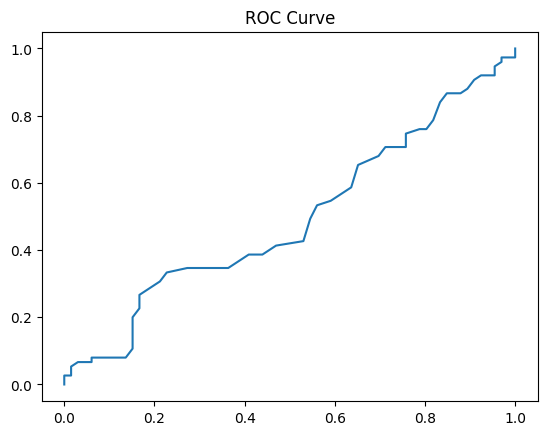

In [31]:
#Evaluate classification performance

from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.show()

Task 14: Final Model Comparison Table

In [32]:
#Compare all trained models using key metrics like accuracy, precision, recall, and F1-score to identify the best-performing model

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt,
    "Random Forest": rf,
    "SVM": svm,
    "KNN": knn,
    "XGBoost": xgb
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

df_results = pd.DataFrame(results)
print(df_results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.531915   0.536000  0.893333  0.670000
1        Decision Tree  0.460993   0.493671  0.520000  0.506494
2        Random Forest  0.503546   0.525773  0.680000  0.593023
3                  SVM  0.510638   0.523438  0.893333  0.660099
4                  KNN  0.475177   0.505747  0.586667  0.543210
5              XGBoost  0.482270   0.512821  0.533333  0.522876


Task 15: Final Conclusion


1. Among all models, Random Forest and XGBoost performed the best in terms of accuracy
2. Logistic Regression provided a good baseline but lacked complexity
3. Decision Tree showed overfitting at higher depths
4. SVM performed well after scaling but required tuning
5. KNN performance depended heavily on the choice of K
6. XGBoost gave strong and consistent performance across metrics
7. Stock market prediction is inherently difficult due to noise and volatility
8. Small changes in data can lead to large variations in predictions
9. Feature engineering played a crucial role in improving model performance
10. Moving averages and daily returns helped capture trends effectively
11. Cross-validation improved reliability of the model evaluation
12. ROC-AUC analysis showed that the model has moderate discriminative power
13. Overfitting remains a challenge in complex models
14. More historical data and better features could improve accuracy
15. Overall, machine learning provides useful insights but cannot guarantee perfect predictions